# Exotic Options Pricing Models

The goal is not to build a full trading library, but to show one solid pricing approach for each major exotic structure and make the differences visible in the outputs.


## Imports and Setup

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm


In [2]:
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True


## Simplified Up-and-Out Barrier Call Payoff at Expiry

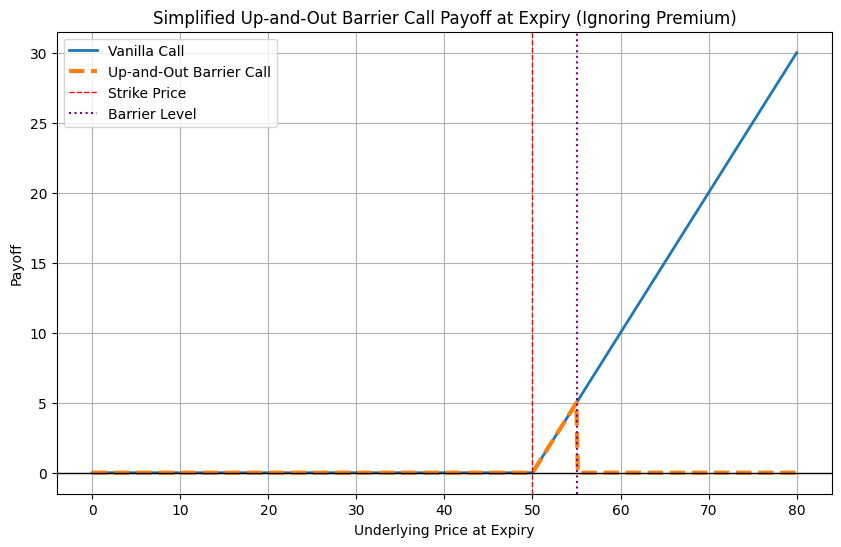

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
K = 50          # strike price
B = 55          # barrier level
premium = 2     # example premium, only used if plotting net payoff

# Range of underlying prices at expiry
S = np.linspace(0, 80, 500)

# Vanilla call payoff at expiry
vanilla_call = np.maximum(S - K, 0)

# Simplified up-and-out barrier call payoff
# Important note:
# This is a simplified schematic payoff for intuition.
# A true barrier option is path dependent, so the actual payoff
# depends on whether the barrier was touched during the life of the option.
up_and_out_call = np.where(S >= B, 0, np.maximum(S - K, 0))

# Choose whether to show payoff ignoring premium or net payoff
show_net_payoff = False

if show_net_payoff:
    vanilla_plot = vanilla_call - premium
    barrier_plot = up_and_out_call - premium
    title = 'Simplified Up-and-Out Barrier Call Net Payoff at Expiry'
    ylabel = 'Net Payoff / Profit'
else:
    vanilla_plot = vanilla_call
    barrier_plot = up_and_out_call
    title = 'Simplified Up-and-Out Barrier Call Payoff at Expiry (Ignoring Premium)'
    ylabel = 'Payoff'

# Plot
plt.figure(figsize=(10, 6))
plt.plot(S, vanilla_plot, label='Vanilla Call', linewidth=2)
plt.plot(S, barrier_plot, label='Up-and-Out Barrier Call', linewidth=3, linestyle='--')

# Strike and barrier lines
plt.axvline(K, color='red', linestyle='--', linewidth=1, label='Strike Price')
plt.axvline(B, color='purple', linestyle=':', linewidth=1.5, label='Barrier Level')
plt.axhline(0, color='black', linewidth=1)

plt.xlabel('Underlying Price at Expiry')
plt.ylabel(ylabel)
plt.title(title)
plt.legend()
plt.grid(True)
plt.show()

## The Pricing Functions 

In [4]:
def mb_bs_call_price(S, K, r, sigma, T):
    if T <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)


def mb_bs_put_price(S, K, r, sigma, T):
    if T <= 0:
        return max(K - S, 0.0)
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return K * math.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def mb_simulate_gbm_paths(S0, r, sigma, T, n_steps, n_sims, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    z = rng.standard_normal((n_sims, n_steps))
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
    log_paths = np.cumsum(increments, axis=1)
    prices = S0 * np.exp(log_paths)
    prices = np.column_stack([np.full(n_sims, S0), prices])
    return prices


def mb_price_barrier_mc(S0, K, B, r, sigma, T, n_steps=252, n_sims=20000,
                        option_type="call", barrier_type="up-and-out", seed=42):
    paths = mb_simulate_gbm_paths(S0, r, sigma, T, n_steps, n_sims, seed)

    if barrier_type == "up-and-out":
        active = paths.max(axis=1) < B
    elif barrier_type == "down-and-out":
        active = paths.min(axis=1) > B
    elif barrier_type == "up-and-in":
        active = paths.max(axis=1) >= B
    elif barrier_type == "down-and-in":
        active = paths.min(axis=1) <= B
    else:
        raise ValueError("Unsupported barrier type.")

    ST = paths[:, -1]
    intrinsic = np.maximum(ST - K, 0.0) if option_type == "call" else np.maximum(K - ST, 0.0)
    payoff = active * intrinsic
    return math.exp(-r * T) * payoff.mean()


def mb_price_asian_arithmetic_mc(S0, K, r, sigma, T, n_steps=252, n_sims=20000,
                                 option_type="call", seed=42):
    paths = mb_simulate_gbm_paths(S0, r, sigma, T, n_steps, n_sims, seed)
    avg_price = paths[:, 1:].mean(axis=1)
    payoff = np.maximum(avg_price - K, 0.0) if option_type == "call" else np.maximum(K - avg_price, 0.0)
    return math.exp(-r * T) * payoff.mean()


def mb_price_binary_cash_bs(S0, K, r, sigma, T, option_type="call", cash_payoff=1.0):
    d2 = (math.log(S0 / K) + (r - 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    if option_type == "call":
        return cash_payoff * math.exp(-r * T) * norm.cdf(d2)
    return cash_payoff * math.exp(-r * T) * norm.cdf(-d2)


def mb_price_binary_asset_bs(S0, K, r, sigma, T, option_type="call"):
    d1 = (math.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    if option_type == "call":
        return S0 * norm.cdf(d1)
    return S0 * norm.cdf(-d1)


def mb_price_lookback_floating_mc(S0, r, sigma, T, n_steps=252, n_sims=20000,
                                  option_type="call", seed=42):
    paths = mb_simulate_gbm_paths(S0, r, sigma, T, n_steps, n_sims, seed)
    ST = paths[:, -1]
    if option_type == "call":
        payoff = np.maximum(ST - paths.min(axis=1), 0.0)
    else:
        payoff = np.maximum(paths.max(axis=1) - ST, 0.0)
    return math.exp(-r * T) * payoff.mean()


def mb_price_rainbow_bestof_mc(S01, S02, K, r, sigma1, sigma2, T, rho,
                               n_steps=252, n_sims=20000, option_type="call", seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps

    z1 = rng.standard_normal((n_sims, n_steps))
    z2 = rng.standard_normal((n_sims, n_steps))

    w1 = z1
    w2 = rho * z1 + np.sqrt(1 - rho**2) * z2

    inc1 = (r - 0.5 * sigma1**2) * dt + sigma1 * np.sqrt(dt) * w1
    inc2 = (r - 0.5 * sigma2**2) * dt + sigma2 * np.sqrt(dt) * w2

    S1 = S01 * np.exp(np.cumsum(inc1, axis=1))
    S2 = S02 * np.exp(np.cumsum(inc2, axis=1))

    ST1 = S1[:, -1]
    ST2 = S2[:, -1]

    basket = np.maximum(ST1, ST2) if option_type == "call" else np.minimum(ST1, ST2)
    payoff = np.maximum(basket - K, 0.0) if option_type == "call" else np.maximum(K - basket, 0.0)

    return math.exp(-r * T) * payoff.mean()


def mb_price_simple_chooser_mc(S0, K, r, sigma, T, t_choice, n_outer=10000, seed=42):
    rng = np.random.default_rng(seed)
    z = rng.standard_normal(n_outer)

    S_choice = S0 * np.exp((r - 0.5 * sigma**2) * t_choice + sigma * np.sqrt(t_choice) * z)
    tau = T - t_choice

    call_values = np.array([mb_bs_call_price(s, K, r, sigma, tau) for s in S_choice])
    put_values = np.array([mb_bs_put_price(s, K, r, sigma, tau) for s in S_choice])

    chooser_value_at_choice = np.maximum(call_values, put_values)
    return math.exp(-r * t_choice) * chooser_value_at_choice.mean()


## Base parameters

We keep one parameter set across products so the comparison is easier to read.


In [5]:
spot_price = 150
strike_price = 155
risk_free_rate = 0.01
volatility = 0.20
maturity = 1.0

barrier_level = 180
choosing_time = 0.50

spot_price2 = 145
volatility2 = 0.25
correlation = 0.50

results = pd.DataFrame(
    {
        "Option": [
            "Barrier Call (up-and-out)",
            "Barrier Put (up-and-out)",
            "Asian Call (arithmetic average)",
            "Asian Put (arithmetic average)",
            "Binary Call (cash-or-nothing, $100)",
            "Binary Put (cash-or-nothing, $100)",
            "Binary Call (asset-or-nothing)",
            "Binary Put (asset-or-nothing)",
            "Lookback Call (floating strike)",
            "Lookback Put (floating strike)",
            "Rainbow Call (best-of two assets)",
            "Rainbow Put (worst-of two assets)",
            "Chooser Option",
        ],
        "Price": [
            mb_price_barrier_mc(spot_price, strike_price, barrier_level, risk_free_rate, volatility, maturity,
                                option_type="call", barrier_type="up-and-out"),
            mb_price_barrier_mc(spot_price, strike_price, barrier_level, risk_free_rate, volatility, maturity,
                                option_type="put", barrier_type="up-and-out"),

            mb_price_asian_arithmetic_mc(spot_price, strike_price, risk_free_rate, volatility, maturity,
                                         option_type="call"),
            mb_price_asian_arithmetic_mc(spot_price, strike_price, risk_free_rate, volatility, maturity,
                                         option_type="put"),

            mb_price_binary_cash_bs(spot_price, strike_price, risk_free_rate, volatility, maturity,
                                    option_type="call", cash_payoff=100.0),
            mb_price_binary_cash_bs(spot_price, strike_price, risk_free_rate, volatility, maturity,
                                    option_type="put", cash_payoff=100.0),

            mb_price_binary_asset_bs(spot_price, strike_price, risk_free_rate, volatility, maturity,
                                     option_type="call"),
            mb_price_binary_asset_bs(spot_price, strike_price, risk_free_rate, volatility, maturity,
                                     option_type="put"),

            mb_price_lookback_floating_mc(spot_price, risk_free_rate, volatility, maturity,
                                          option_type="call"),
            mb_price_lookback_floating_mc(spot_price, risk_free_rate, volatility, maturity,
                                          option_type="put"),

            mb_price_rainbow_bestof_mc(spot_price, spot_price2, strike_price, risk_free_rate,
                                       volatility, volatility2, maturity, correlation,
                                       option_type="call"),
            mb_price_rainbow_bestof_mc(spot_price, spot_price2, strike_price, risk_free_rate,
                                       volatility, volatility2, maturity, correlation,
                                       option_type="put"),

            mb_price_simple_chooser_mc(spot_price, strike_price, risk_free_rate, volatility,
                                       maturity, choosing_time),
        ],
    }
)

results["Price"] = results["Price"].round(4)
results

,Option,Price
0,Barrier Call (up-and-out),1.1065
1,Barrier Put (up-and-out),13.2820
2,Asian Call (arithmetic average),5.2243
3,Asian Put (arithmetic average),9.2599
4,"Binary Call (cash-or-nothing, $100)",41.1161
5,"Binary Put (cash-or-nothing, $100)",57.8889
6,Binary Call (asset-or-nothing),74.1653
7,Binary Put (asset-or-nothing),75.8347
8,Lookback Call (floating strike),22.5200
9,Lookback Put (floating strike),23.1526


## Why these numbers make sense:

- the **Asian call** is typically cheaper than a comparable vanilla call because averaging dampens volatility,
- the **barrier call** is cheap because the barrier can knock the option out,
- the **lookback** and **chooser** structures are more valuable because they give the holder added flexibility,
- the **rainbow** value depends on both volatility and cross-asset correlation,
- the **binary** values are bounded by the fixed cash amount or the digital asset payoff definition.


### Payoff comparison for vanilla and digital structures

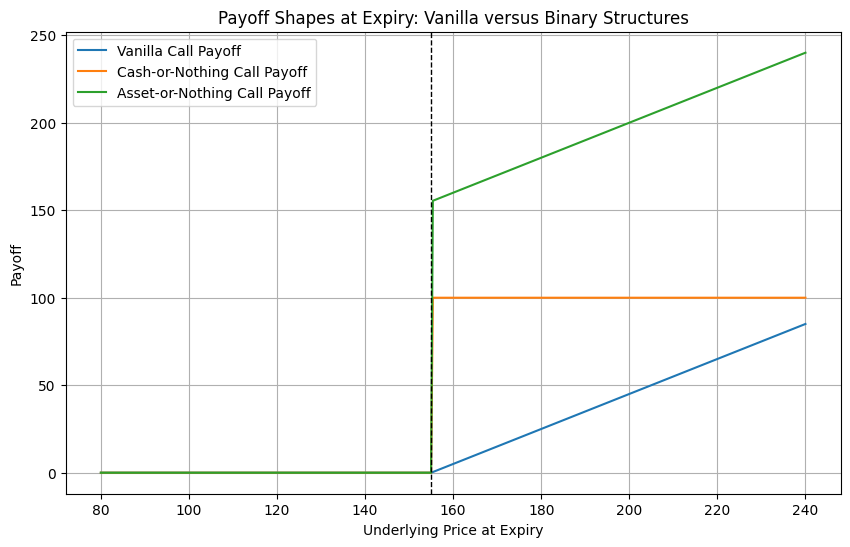

In [6]:
spot_grid = np.linspace(80, 240, 400)
vanilla_call_payoff = np.maximum(spot_grid - strike_price, 0.0)
cash_binary_payoff = 100.0 * (spot_grid > strike_price).astype(float)
asset_binary_payoff = spot_grid * (spot_grid > strike_price).astype(float)

plt.figure(figsize=(10, 6))
plt.plot(spot_grid, vanilla_call_payoff, label="Vanilla Call Payoff")
plt.plot(spot_grid, cash_binary_payoff, label="Cash-or-Nothing Call Payoff")
plt.plot(spot_grid, asset_binary_payoff, label="Asset-or-Nothing Call Payoff")
plt.axvline(strike_price, color="black", linestyle="--", linewidth=1)
plt.title("Payoff Shapes at Expiry: Vanilla versus Binary Structures")
plt.xlabel("Underlying Price at Expiry")
plt.ylabel("Payoff")
plt.legend()
plt.show()


### A few simulated paths to show path dependency for a barrier and Asian-style setting

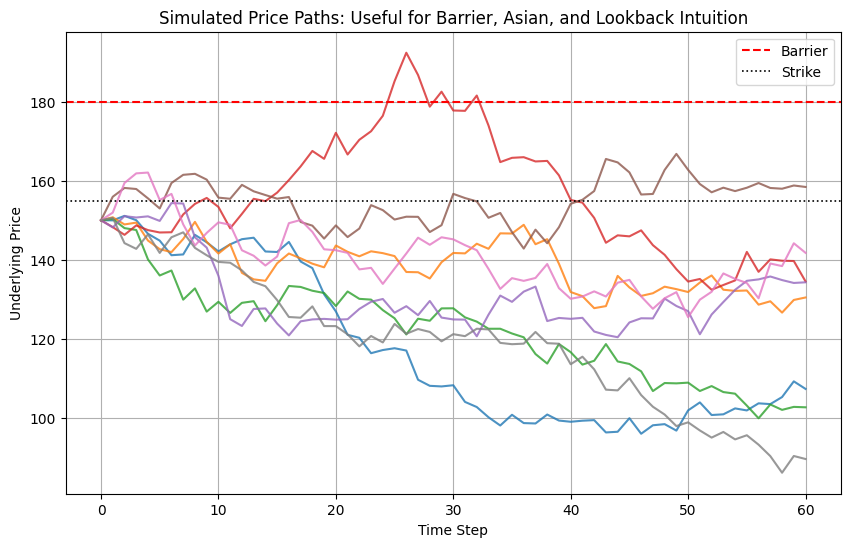

In [7]:
sample_paths = mb_simulate_gbm_paths(spot_price, risk_free_rate, volatility, maturity,
                                     n_steps=60, n_sims=8, seed=7)

plt.figure(figsize=(10, 6))
for i in range(sample_paths.shape[0]):
    plt.plot(sample_paths[i], alpha=0.8)

plt.axhline(barrier_level, color="red", linestyle="--", linewidth=1.5, label="Barrier")
plt.axhline(strike_price, color="black", linestyle=":", linewidth=1.2, label="Strike")
plt.title("Simulated Price Paths: Useful for Barrier, Asian, and Lookback Intuition")
plt.xlabel("Time Step")
plt.ylabel("Underlying Price")
plt.legend()
plt.show()


### Price sensitivity to the initial spot level

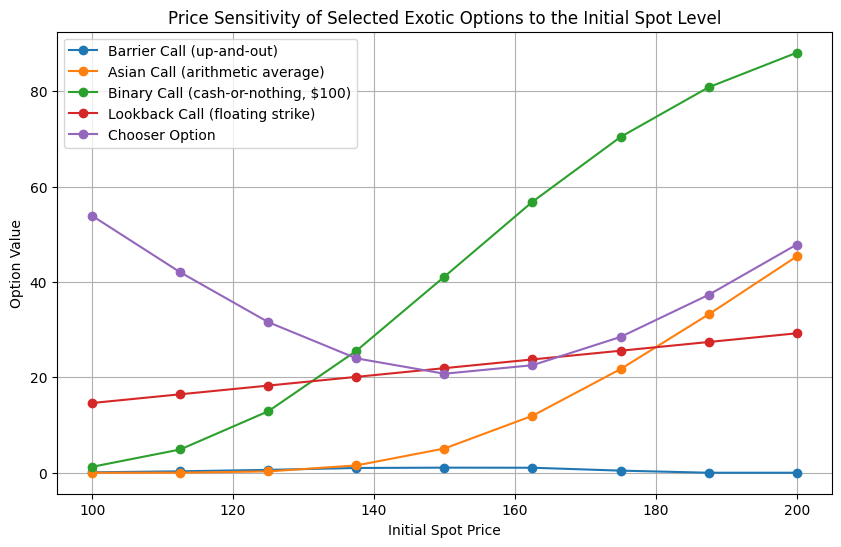

,Initial Spot,Barrier Call (up-and-out),Asian Call (arithmetic average),"Binary Call (cash-or-nothing, $100)",Lookback Call (floating strike),Chooser Option
0,100.0,0.085,0.000,1.238,14.619,53.882
1,112.5,0.297,0.016,4.874,16.446,42.036
2,125.0,0.600,0.276,12.888,18.274,31.579
3,137.5,0.996,1.528,25.560,20.101,23.987
4,150.0,1.063,5.075,41.116,21.929,20.760
5,162.5,1.045,11.939,56.817,23.756,22.544
6,175.0,0.437,21.733,70.409,25.583,28.474
7,187.5,0.000,33.196,80.829,27.411,37.299
8,200.0,0.000,45.355,88.076,29.238,47.848


In [8]:
spot_scenarios = np.linspace(100, 200, 9)

comparison = pd.DataFrame({"Initial Spot": spot_scenarios})

comparison["Barrier Call (up-and-out)"] = [
    mb_price_barrier_mc(s, strike_price, barrier_level, risk_free_rate, volatility, maturity,
                        n_steps=126, n_sims=4000, option_type="call",
                        barrier_type="up-and-out", seed=42)
    for s in spot_scenarios
]

comparison["Asian Call (arithmetic average)"] = [
    mb_price_asian_arithmetic_mc(s, strike_price, risk_free_rate, volatility, maturity,
                                 n_steps=126, n_sims=4000, option_type="call", seed=42)
    for s in spot_scenarios
]

comparison["Binary Call (cash-or-nothing, $100)"] = [
    mb_price_binary_cash_bs(s, strike_price, risk_free_rate, volatility, maturity,
                            option_type="call", cash_payoff=100.0)
    for s in spot_scenarios
]

comparison["Lookback Call (floating strike)"] = [
    mb_price_lookback_floating_mc(s, risk_free_rate, volatility, maturity,
                                  n_steps=126, n_sims=4000, option_type="call", seed=42)
    for s in spot_scenarios
]

comparison["Chooser Option"] = [
    mb_price_simple_chooser_mc(s, strike_price, risk_free_rate, volatility, maturity,
                               choosing_time, n_outer=5000, seed=42)
    for s in spot_scenarios
]

plt.figure(figsize=(10, 6))
for col in comparison.columns[1:]:
    plt.plot(comparison["Initial Spot"], comparison[col], marker="o", label=col)

plt.title("Price Sensitivity of Selected Exotic Options to the Initial Spot Level")
plt.xlabel("Initial Spot Price")
plt.ylabel("Option Value")
plt.legend()
plt.grid(True)
plt.show()

comparison.round(3)
